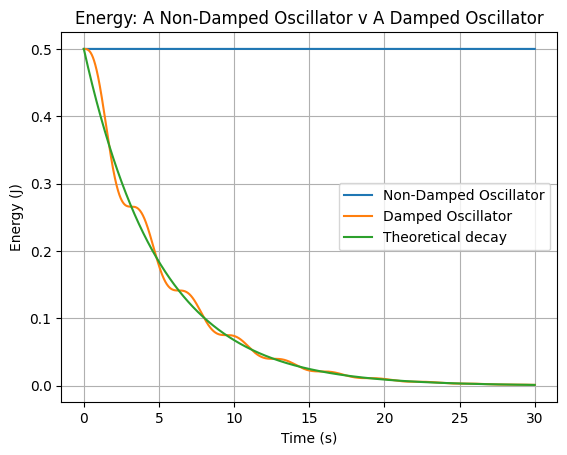

In [ ]:
#non-damped harmonic system

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
#importing required libraries

#parameters
omega = 1.0 #natural frequency
gamma = 0.2 #damping effect

#defining equations
def harmonic_oscillator(t,y):
  x,v=y
  dxdt= v
  dvdt = -omega**2*x
  return [dxdt,dvdt]

def damped_oscillator(t,y):
  x,v=y
  dxdt=v
  dvdt=-gamma*v-omega**2*x
  return [dxdt,dvdt]

#time
t_span=(0,30)
t_eval=np.linspace(0,30,10000)


#initial conditions
y0=[1.0,0.0]

#solving equations
sol=solve_ivp(harmonic_oscillator,t_span,y0, t_eval=t_eval,rtol=1e-9,atol=1e-12)
sol_damp=solve_ivp(damped_oscillator,t_span,y0,t_eval=t_eval, rtol=1e-9,atol=1e-12)

#extracting solutions
t=sol.t
x_non=sol.y[0]
v_non=sol.y[1]

t=sol_damp.t
x_damp=sol_damp.y[0]
v_damp=sol_damp.y[1]

#energy calculations

#kinetic energy
T_non= 0.5*v_non**2
T_damp=0.5*v_damp**2

#potential energy
V_non=0.5*omega**2*x_non**2
V_damp=0.5*omega**2*x_damp**2

#total energy
E_non=T_non+V_non
E_damp=T_damp+V_damp

#theoretical decaying factor
E0=E_damp[0]
E_env=E0*np.exp(-gamma*t)

#plotting
plt.plot(t,E_non, label="Non-Damped Oscillator")
plt.plot(t,E_damp, label="Damped Oscillator")
plt.plot(t,E_env, label="Theoretical decay")
plt.title("Energy: A Non-Damped Oscillator v A Damped Oscillator")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.grid(True)
plt.legend()
plt.show()



